In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("final.csv")

In [3]:
df.head()

,hadm_id,subject_id,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,hospital_expire_flag
0,20044587.0,10023771,70,M,0.883333,9.433333,141.500000,18.166667,7.0,0
1,20093566.0,10039708,46,F,6.028571,7.922222,139.428571,26.714286,7.0,0
2,20192635.0,10037928,78,F,1.225000,11.000000,138.500000,23.000000,3.0,0
3,20199380.0,10005909,40,F,0.580000,9.925000,138.000000,7.200000,1.0,0
4,20214994.0,10003400,72,F,0.735294,9.248649,141.029412,15.176471,7.0,0


In [4]:
df.shape

(251, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hadm_id               251 non-null    float64
 1   subject_id            251 non-null    int64  
 2   anchor_age            251 non-null    int64  
 3   gender                251 non-null    object 
 4   Creatinine            251 non-null    float64
 5   Hemoglobin            251 non-null    float64
 6   Sodium                251 non-null    float64
 7   Urea Nitrogen         251 non-null    float64
 8   WBC                   251 non-null    float64
 9   hospital_expire_flag  251 non-null    int64  
dtypes: float64(6), int64(3), object(1)
memory usage: 19.7+ KB


In [6]:
df.isnull().sum()

hadm_id                 0
subject_id              0
anchor_age              0
gender                  0
Creatinine              0
Hemoglobin              0
Sodium                  0
Urea Nitrogen           0
WBC                     0
hospital_expire_flag    0
dtype: int64

In [7]:
X = df.drop(columns=["hadm_id","subject_id","hospital_expire_flag"])
Y = df["hospital_expire_flag"]

In [8]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC
0,70,M,0.883333,9.433333,141.500000,18.166667,7.0
1,46,F,6.028571,7.922222,139.428571,26.714286,7.0
2,78,F,1.225000,11.000000,138.500000,23.000000,3.0
3,40,F,0.580000,9.925000,138.000000,7.200000,1.0
4,72,F,0.735294,9.248649,141.029412,15.176471,7.0


In [9]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: hospital_expire_flag, dtype: int64

In [10]:
Y.value_counts()

hospital_expire_flag
0    236
1     15
Name: count, dtype: int64

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   anchor_age     251 non-null    int64  
 1   gender         251 non-null    object 
 2   Creatinine     251 non-null    float64
 3   Hemoglobin     251 non-null    float64
 4   Sodium         251 non-null    float64
 5   Urea Nitrogen  251 non-null    float64
 6   WBC            251 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 13.9+ KB


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X["gender"] = le.fit_transform(X["gender"])

In [13]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0


In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42,stratify=Y)

In [15]:
X1 = X.copy()

In [16]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0


In [17]:
X.columns

Index(['anchor_age', 'gender', 'Creatinine', 'Hemoglobin', 'Sodium',
       'Urea Nitrogen', 'WBC'],
      dtype='object')

feature engineering

bun_creatinine_ratio"

In [18]:
X["bun_creatinine_ratio"] = X["Urea Nitrogen"]/X["Creatinine"]

In [19]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,bun_creatinine_ratio
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0,20.566038
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0,4.431280
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0,18.775510
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0,12.413793
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0,20.640000


Renal Dysfunction Flag

In [20]:
X["renal_dyfunction_flag"] = (X["Creatinine"]>=1.5).astype(int)

In [21]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,bun_creatinine_ratio,renal_dyfunction_flag
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0,20.566038,0
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0,4.431280,1
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0,18.775510,0
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0,12.413793,0
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0,20.640000,0


Bleeding & anemia features

In [22]:
X["severe_anemia"] = (X["Hemoglobin"]<9).astype(int)

In [23]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,bun_creatinine_ratio,renal_dyfunction_flag,severe_anemia
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0,20.566038,0,0
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0,4.431280,1,1
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0,18.775510,0,0
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0,12.413793,0,0
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0,20.640000,0,0


Electrolyte failure

In [24]:
X["hypotermia"] = (X["Sodium"]<135).astype(int)

In [25]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,bun_creatinine_ratio,renal_dyfunction_flag,severe_anemia,hypotermia
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0,20.566038,0,0,0
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0,4.431280,1,1,0
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0,18.775510,0,0,0
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0,12.413793,0,0,0
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0,20.640000,0,0,0


In [26]:
X["severe_hyponatremia"] = (X["Sodium"] < 130).astype(int)

In [27]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,bun_creatinine_ratio,renal_dyfunction_flag,severe_anemia,hypotermia,severe_hyponatremia
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0,20.566038,0,0,0,0
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0,4.431280,1,1,0,0
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0,18.775510,0,0,0,0
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0,12.413793,0,0,0,0
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0,20.640000,0,0,0,0


Inflammation / infection stress

In [28]:
X["leukocytosis"] = (X["WBC"] > 11).astype(int)

In [29]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,bun_creatinine_ratio,renal_dyfunction_flag,severe_anemia,hypotermia,severe_hyponatremia,leukocytosis
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0,20.566038,0,0,0,0,0
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0,4.431280,1,1,0,0,0
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0,18.775510,0,0,0,0,0
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0,12.413793,0,0,0,0,0
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0,20.640000,0,0,0,0,0


In [30]:
X["elderly_risk"] = (X["anchor_age"] >= 60).astype(int)

In [31]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,bun_creatinine_ratio,renal_dyfunction_flag,severe_anemia,hypotermia,severe_hyponatremia,leukocytosis,elderly_risk
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0,20.566038,0,0,0,0,0,1
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0,4.431280,1,1,0,0,0,0
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0,18.775510,0,0,0,0,0,1
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0,12.413793,0,0,0,0,0,0
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0,20.640000,0,0,0,0,0,1


In [32]:
X.columns

Index(['anchor_age', 'gender', 'Creatinine', 'Hemoglobin', 'Sodium',
       'Urea Nitrogen', 'WBC', 'bun_creatinine_ratio', 'renal_dyfunction_flag',
       'severe_anemia', 'hypotermia', 'severe_hyponatremia', 'leukocytosis',
       'elderly_risk'],
      dtype='object')

In [33]:
X = X.rename(columns={
    "renal_dyfunction_flag": "renal_dysfunction_flag",
    "hypotermia": "hyponatremia"
})

In [34]:
X.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,bun_creatinine_ratio,renal_dysfunction_flag,severe_anemia,hyponatremia,severe_hyponatremia,leukocytosis,elderly_risk
0,70,1,0.883333,9.433333,141.500000,18.166667,7.0,20.566038,0,0,0,0,0,1
1,46,0,6.028571,7.922222,139.428571,26.714286,7.0,4.431280,1,1,0,0,0,0
2,78,0,1.225000,11.000000,138.500000,23.000000,3.0,18.775510,0,0,0,0,0,1
3,40,0,0.580000,9.925000,138.000000,7.200000,1.0,12.413793,0,0,0,0,0,0
4,72,0,0.735294,9.248649,141.029412,15.176471,7.0,20.640000,0,0,0,0,0,1


In [35]:
X.columns

Index(['anchor_age', 'gender', 'Creatinine', 'Hemoglobin', 'Sodium',
       'Urea Nitrogen', 'WBC', 'bun_creatinine_ratio',
       'renal_dysfunction_flag', 'severe_anemia', 'hyponatremia',
       'severe_hyponatremia', 'leukocytosis', 'elderly_risk'],
      dtype='object')

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.33,stratify=Y,random_state=42)

In [37]:
X_train.head()

,anchor_age,gender,Creatinine,Hemoglobin,Sodium,Urea Nitrogen,WBC,bun_creatinine_ratio,renal_dysfunction_flag,severe_anemia,hyponatremia,severe_hyponatremia,leukocytosis,elderly_risk
107,78,0,1.15,12.600000,138.666667,14.500000,35.0,12.608696,0,0,0,0,1,1
249,53,1,1.80,13.075000,143.200000,37.400000,7.0,20.777778,1,0,0,0,0,0
247,53,1,1.70,13.700000,140.500000,18.000000,7.0,10.588235,1,0,0,0,0,0
210,83,1,1.30,13.866667,139.333333,17.333333,7.0,13.333333,0,0,0,0,0,1
193,53,0,0.40,12.250000,138.000000,7.000000,7.0,17.500000,0,0,0,0,0,0


In [38]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

In [39]:
rf.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [40]:
y_proba = rf.predict_proba(X_test)[:, 1]

In [41]:
thresold = 0.15
y_pred_custom = (y_proba >= thresold).astype(int)

In [42]:
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score

In [43]:
print(classification_report(Y_test,y_pred_custom))
print(accuracy_score(Y_test,y_pred_custom))

              precision    recall  f1-score   support

           0       0.96      0.83      0.89        78
           1       0.13      0.40      0.20         5

    accuracy                           0.81        83
   macro avg       0.54      0.62      0.55        83
weighted avg       0.91      0.81      0.85        83

0.8072289156626506


In [44]:
print(roc_auc_score(Y_test,y_pred_custom))

0.6166666666666667


In [45]:
from xgboost import XGBClassifier
neg = (Y_train == 0).sum()
pos =(Y_train == 1).sum()
scale_pos_weight = neg/pos
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    reg_lambda=1.0,
    gamma=0.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

In [46]:
xgb.fit(X_train,Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [47]:
y_proba = xgb.predict_proba(X_test)[:, 1]

In [48]:
from sklearn.metrics import classification_report ,roc_auc_score

In [49]:
thresold = 0.15
y_pred_custom = (y_proba >= thresold).astype(int)
print(classification_report(Y_test,y_pred_custom,digits=3))

              precision    recall  f1-score   support

           0      0.972     0.885     0.926        78
           1      0.250     0.600     0.353         5

    accuracy                          0.867        83
   macro avg      0.611     0.742     0.640        83
weighted avg      0.928     0.867     0.892        83



In [50]:
print(roc_auc_score(Y_test,y_proba))

0.882051282051282


In [51]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(Y_test,y_pred_custom)

In [52]:
print(accuracy_score(Y_test,y_pred_custom))

0.8674698795180723


In [53]:
print(cm)

[[69  9]
 [ 2  3]]


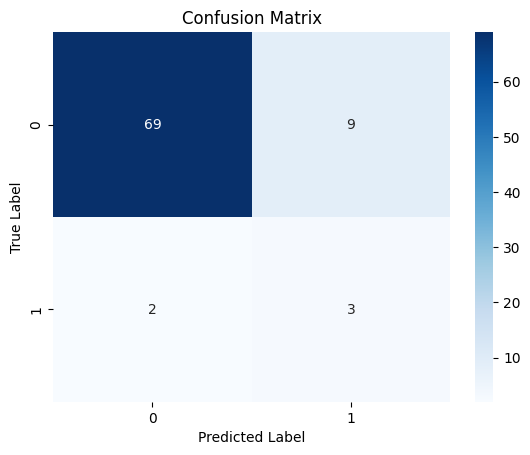

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [55]:
import joblib

joblib.dump(xgb, "xgb_mortality_model.pkl")

['xgb_mortality_model.pkl']

In [56]:
feature_cols = list(X.columns)
joblib.dump(feature_cols, "xgb_feature_columns.pkl")

['xgb_feature_columns.pkl']

In [57]:
import joblib
import pandas as pd

# load model and features
xgb = joblib.load("xgb_mortality_model.pkl")
feature_cols = joblib.load("xgb_feature_columns.pkl")

# new patient input (example)
input_data = {
    "anchor_age": 65,
    "gender": 1,
    "Creatinine": 2.1,
    "Hemoglobin": 8.5,
    "Sodium": 131,
    "Urea Nitrogen": 40,
    "WBC": 14.2,
    "bun_creatinine_ratio": 40 / 2.1,
    "renal_dysfunction_flag": 1,
    "severe_anemia": 1,
    "hyponatremia": 1,
    "severe_hyponatremia": 0,
    "leukocytosis": 1,
    "elderly_risk": 1
}

# IMPORTANT: align with training features
X_input = pd.DataFrame([input_data])[feature_cols]

# predict mortality risk
prob = xgb.predict_proba(X_input)[0, 1]
print("Mortality risk %:", round(prob * 100, 2))


Mortality risk %: 70.21


In [58]:
X.shape

(251, 14)

In [59]:
X.columns

Index(['anchor_age', 'gender', 'Creatinine', 'Hemoglobin', 'Sodium',
       'Urea Nitrogen', 'WBC', 'bun_creatinine_ratio',
       'renal_dysfunction_flag', 'severe_anemia', 'hyponatremia',
       'severe_hyponatremia', 'leukocytosis', 'elderly_risk'],
      dtype='object')

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report,average_precision_score

lr = LogisticRegression(max_iter=2000, class_weight="balanced")
lr.fit(X_train, Y_train)

lr_proba = lr.predict_proba(X_test)[:, 1]
print("Logistic Regression ROC-AUC:", roc_auc_score(Y_test, lr_proba))
print(classification_report(Y_test, (lr_proba >= 0.15).astype(int)))
print("Logistic Regression PR-AUC:", average_precision_score(Y_test, lr_proba))



Logistic Regression ROC-AUC: 0.7487179487179487
              precision    recall  f1-score   support

           0       0.98      0.59      0.74        78
           1       0.11      0.80      0.20         5

    accuracy                           0.60        83
   macro avg       0.54      0.69      0.47        83
weighted avg       0.93      0.60      0.70        83

Logistic Regression PR-AUC: 0.3274178403755868


In [61]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, Y_train)

nb_proba = nb.predict_proba(X_test)[:, 1]
print("Naive Bayes ROC-AUC:", roc_auc_score(Y_test, nb_proba))
print(classification_report(Y_test, (nb_proba >= 0.15).astype(int)))
print("Naive Bayes PR-AUC:", average_precision_score(Y_test, nb_proba))

Naive Bayes ROC-AUC: 0.5923076923076923
              precision    recall  f1-score   support

           0       0.96      0.87      0.91        78
           1       0.17      0.40      0.24         5

    accuracy                           0.84        83
   macro avg       0.56      0.64      0.57        83
weighted avg       0.91      0.84      0.87        83

Naive Bayes PR-AUC: 0.15502425360388059


In [62]:
from sklearn.svm import SVC

svm = SVC(probability=True, class_weight="balanced", random_state=42)
svm.fit(X_train, Y_train)

svm_proba = svm.predict_proba(X_test)[:, 1]
print("SVM ROC-AUC:", roc_auc_score(Y_test, svm_proba))
print(classification_report(Y_test, (svm_proba >= 0.15).astype(int)))
print("SVM PR-AUC:", average_precision_score(Y_test, svm_proba))



SVM ROC-AUC: 0.6128205128205128
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        78
           1       0.20      0.40      0.27         5

    accuracy                           0.87        83
   macro avg       0.58      0.65      0.60        83
weighted avg       0.91      0.87      0.89        83

SVM PR-AUC: 0.34745808182427906


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, Y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
print("Random Forest ROC-AUC:", roc_auc_score(Y_test, rf_proba))
print(classification_report(Y_test, (rf_proba >= 0.15).astype(int)))
print("Random Forest PR-AUC:", average_precision_score(Y_test, rf_proba))

Random Forest ROC-AUC: 0.7871794871794872
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        78
           1       0.14      0.40      0.21         5

    accuracy                           0.82        83
   macro avg       0.55      0.62      0.55        83
weighted avg       0.91      0.82      0.86        83

Random Forest PR-AUC: 0.16896121351766513


In [64]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    reg_lambda=1.0,
    gamma=0.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, Y_train)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
print("XGBoost ROC-AUC:", roc_auc_score(Y_test, xgb_proba))
print(classification_report(Y_test, (xgb_proba >= 0.15).astype(int)))
print("Xgboost PR-AUC:", average_precision_score(Y_test, xgb_proba))


XGBoost ROC-AUC: 0.8846153846153847
              precision    recall  f1-score   support

           0       0.97      0.90      0.93        78
           1       0.27      0.60      0.38         5

    accuracy                           0.88        83
   macro avg       0.62      0.75      0.65        83
weighted avg       0.93      0.88      0.90        83

Xgboost PR-AUC: 0.5811111111111111
